In [1]:
import pandas as pd
import os 

### Loading and preparing the data

In [2]:
MAIN_DIR = "/home/joan/Desktop/PROJECTS/Glioblastomas/"
RESULTS = f"{MAIN_DIR}/RESULTS-GBM_4-cohorts_UMAP-Risks"
os.makedirs(f"{RESULTS}", exist_ok=True)

daysXmonth = 365/12
voxel_size = (0.5**3) * (1/1000) # 0.5 (mm³/voxel) X 0.001 (cm³/mm³)   

In [3]:
hcpex_complete = pd.read_csv(f"{RESULTS}/data-clinical_parcellation-hcpex_4-cohorts.csv", sep=",")
aal3_complete = pd.read_csv(f"{RESULTS}/data-clinical_parcellation-aal3_4-cohorts.csv", sep=",")

In [4]:
metrics_covariates = [
    'size', 'density', 'avg_degree', 
    'avg_clustering', 'modularity', 'global_efficiency', 'avg_local_efficiency', 'avg_shortest_path_length', 
    'avg_participation_coef', 'avg_eigenvector_centrality', 'avg_betweenness_centrality', 'avg_closeness_centrality', 'avg_edge_betwenness_centrality', 'avg_percolation_centrality', 
    'deg_assortativity', 'powerlaw_exponent', 'LLR_distribution', 's_metric_SF', 'avg_rich_club_coef'
]

clinical_covariates = [
    'age', 'sex', 'eor', 'mgmt', 'kps (preop)'
]

tract_covariates = [
    'Whole TDMap', 'Whole lesion TDMap'
]

morphology_covariates = [
    "Whole tumor size (voxels)"
]

survival_covariates = [
    'cohort', 'site', 
    'OS (days) - corrected', 'status'
]

In [5]:
#hcpex_complete.loc[hcpex_complete['size'],"size"] = hcpex_complete.loc[hcpex_complete['size'],"size"] / 421.0 # Also doesn't seem to work

In [6]:
hcpex_metrics = hcpex_complete[
    survival_covariates+metrics_covariates+tract_covariates+morphology_covariates
].copy().dropna()
print(f"HCPEx -- N={len(hcpex_metrics)} ({len(hcpex_complete)-len(hcpex_metrics)} samples with 'NaN' entries discarded)")

aal3_metrics = aal3_complete[
    survival_covariates+metrics_covariates+tract_covariates+morphology_covariates
].copy().dropna()
print(f"AAL3 -- N={len(aal3_metrics)} ({len(aal3_complete)-len(aal3_metrics)} samples with 'NaN' entries discarded)")

HCPEx -- N=997 (2 samples with 'NaN' entries discarded)
AAL3 -- N=997 (2 samples with 'NaN' entries discarded)


In [7]:
from utils.UMAP_utils import *
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
)
from utils.metrics import clustering_metrics, ranking_OS_topological_risk, topological_risk_concordance_index, topological_risk_kendalltau
from sklearn.cluster import KMeans, DBSCAN, MeanShift, SpectralClustering, estimate_bandwidth, HDBSCAN

/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## UMAP embeddings: Looking for and exploiting hidden nonlinear interactions

In [ ]:
##############################
### Split into train and test
custom = True
if custom is True:
    hcpex_train = hcpex_metrics.loc[hcpex_metrics["cohort"]<=1].copy() # UCSF + UPENN
    hcpex_test = hcpex_metrics.loc[hcpex_metrics["cohort"]>1].copy() # TCGA + RHUH
else:
    from sklearn.model_selection import train_test_split
    hcpex_train, hcpex_test = train_test_split(
        hcpex_metrics,
        test_size=0.2,       
        random_state=None,      
        shuffle=True,          
        stratify=hcpex_metrics["status"]
    )
    hcpex_train = hcpex_train.copy()
    hcpex_test  = hcpex_test.copy()

##############################
### These will be used to define the mapping between cluster labels and topological risk
mask_train = hcpex_train["status"]==1
os_train = hcpex_train["OS (days) - corrected"].values #hcpex_train.loc[mask_train, "OS (days) - corrected"],
status_train = hcpex_train["status"].values

##############################
### Standadizing the test sampmle based on the training distribution
st = 1
if st == 1:
    standard = StandardScaler(with_mean=True, with_std=True)
    hcpex_standard_train = standard.fit_transform(hcpex_train[metrics_covariates])
    hcpex_standard_test = standard.transform(hcpex_test[metrics_covariates])
    data_train, data_test = hcpex_standard_train.copy(), hcpex_standard_test.copy()
elif st == 2:
    minmax = MinMaxScaler(feature_range=(0,1), clip=False)
    hcpex_minmax_train = minmax.fit_transform(hcpex_train[metrics_covariates])
    hcpex_minmax_test = minmax.transform(hcpex_test[metrics_covariates])
    data_train, data_test = hcpex_minmax_train.copy(), hcpex_minmax_test.copy()
elif st == 3:
    robust = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), unit_variance=False)
    hcpex_robust_train = robust.fit_transform(hcpex_train[metrics_covariates])
    hcpex_robust_test = robust.transform(hcpex_test[metrics_covariates])
    data_train, data_test = hcpex_robust_train.copy(), hcpex_robust_test.copy()
elif st == 4:
    powerT = PowerTransformer(method='yeo-johnson', standardize=True)
    hcpex_powerT_train = powerT.fit_transform(hcpex_train[metrics_covariates])
    hcpex_powerT_test = powerT.transform(hcpex_test[metrics_covariates])
    data_train, data_test = hcpex_powerT_train.copy(), hcpex_powerT_test.copy()

N_train, N_test = len(data_train), len(data_test)
print("Train:", N_train, "Test:", N_test)

##############################
# Umap parameters --> to vary (https://umap-learn.readthedocs.io/en/latest/parameters.html)
umap_args = {
    "n_neighbors": 40,
    "n_components": 2,
    "metric": "euclidean",
    "random_state": 57463,
    "min_dist": .1,
    "spread": 1
}
# How can I fix the randomness?
ranking_method = "median-os"
##############################
### Define the clusterizer --> To vary (https://scikit-learn.org/stable/api/sklearn.cluster.html#)
risk_ = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    MeanShift(), # MeanShift requires using the components to define a bandwidth
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
)
clusterizer = MeanShift(
    bandwidth=estimate_bandwidth(
        risk_["umap coordinates: train"], 
        quantile=0.15, 
        n_samples=data_train.shape[0]
    )
)
#clusterizer = KMeans(n_clusters=4)

##############################
### Compute topological risk
umap_risk = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    clusterizer,
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
    cmap="coolwarm", #"gray"#
)

##############################
### Assign topological risk
hcpex_train["topological risk"] = umap_risk["topological risk: train"]
hcpex_test["topological risk"] = umap_risk["topological risk: test"]  

##############################
### Inspecting the outcomes to clarify the final stategy
fig, statistics = plot_umap_outcome(
    hcpex_train,
    umap_risk["umap coordinates: train"], # restricted the plot to 3 components in case of using more components
    hcpex_test,
    umap_risk["umap coordinates: test"],
    daysXmonth,
    umap_risk["color risk"],
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    cmap="coolwarm", #"gray",#
    months=range(0,110,10),
    show_median="all",
    plot=True
) 
statistics = clustering_metrics(umap_risk, statistics)
statistics = topological_risk_kendalltau(statistics)
statistics = topological_risk_concordance_index(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    alpha_CI=0.05,
    n_permutations=5000,
    n_bootstrap=5000,
    random_state=42
)
statistics = ranking_OS_topological_risk(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
)

Train: 861 Test: 136


/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
fig.savefig("./test.svg", dpi=200, format="svg")

### Cox models

In [ ]:
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import joblib
from scipy.stats import chi2
from tqdm import tqdm

hcpex_final_preop_all = hcpex_complete[['age', 'sex']+survival_covariates+metrics_covariates].dropna()
trs = np.concatenate((hcpex_train["topological risk"], hcpex_test["topological risk"]))
hcpex_final_preop_all["topological risk"] = trs

## Comment the following line to use the four cohorts for the fitting procedure
hcpex_final_preop = hcpex_final_preop_all.loc[hcpex_final_preop_all["cohort"]<=1].copy() # UCSF + UPENN

hcpex_final_postop = hcpex_final_preop.copy()
hcpex_final_postop["mgmt"] = hcpex_complete["mgmt"]
hcpex_final_postop["eor"] = hcpex_complete["eor"]
hcpex_final_postop.dropna(inplace=True)

print("Preop scenario: N=", len(hcpex_final_preop))
print("Postop scenario: N=", len(hcpex_final_postop))
print(" ")
tr5_all = hcpex_final_postop.loc[hcpex_final_postop["topological risk"]==5]
patient_example = tr5_all.iloc[[1]]
print(patient_example[["age", "sex", "topological risk", "eor", "mgmt", "OS (days) - corrected", "status"]])

Preop scenario: N= 861
Postop scenario: N= 616
 
    age  sex  topological risk  eor  mgmt  OS (days) - corrected  status
4  64.0    1                 5  1.0   2.0                  313.0     1.0


In [ ]:
def bootstrap_cindex(
        model, 
        data, 
        features,
        status="status",
        survival="OS (days) - corrected",
        n_bootstrap=1000, 
        alpha_CI=0.05,
        seed=42
    ):
    """Return (mean, lower 95% CI, upper 95% CI) of bootstrapped C-index."""
    rng = np.random.default_rng(seed)
    cindex_boot = []
    preds = model.predict_partial_hazard(data[features])
    for ib in tqdm(range(n_bootstrap), desc="Bootsrapping procedure"):
        idx = rng.integers(0, len(data), len(data))
        cidx = concordance_index(data[survival].values[idx], -preds.values[idx], data[status].values[idx])
        cindex_boot.append(cidx)
    cindex_boot = np.array(cindex_boot)
    lower = np.percentile(cindex_boot, 100 * (alpha_CI / 2))
    upper = np.percentile(cindex_boot, 100 * (1 - alpha_CI / 2))

    return (cindex_boot.mean(), lower, upper), cindex_boot


def llr_pvalue(ll_full, ll_reduced, df_diff):
    """Likelihood-ratio test p-value. df_diff = difference in free parameters."""
    lr_stat = 2 * (ll_full - ll_reduced)
    return chi2.sf(lr_stat, df=df_diff)


def print_model_summary(label, model, cindex_train, ci_boot):
    """Pretty-print log-HRs, HRs, p-values and CIs for one model."""
    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'═'*60}")

    summary = model.summary  # lifelines DataFrame
    display_cols = ["exp(coef)", "coef", "exp(coef) lower 95%",
                    "exp(coef) upper 95%", "p"]
    rename = {
        "coef":                  "log-HR",
        "exp(coef)":             "HR",
        "exp(coef) lower 95%":  "HR CI lower",
        "exp(coef) upper 95%":  "HR CI upper",
        "p":                     "p-value",
    }
    out = summary[display_cols].rename(columns=rename)
    out["sig"] = out["p-value"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    )

    with pd.option_context("display.float_format", "{:.8f}".format):
        print(out.to_string())

    print(f"\n  Train C-index : {cindex_train:.4f}")
    print(f"  Bootstrap C-index : {ci_boot[0]:.4f}  "
          f"(95% CI {ci_boot[1]:.4f} – {ci_boot[2]:.4f})")
    print(f"  Log-likelihood    : {model.log_likelihood_:.4f}")
    print(f"  AIC    : {model.AIC_partial_:.4f}")

#### Preoperative model

In [ ]:
# ── Model M1 ──────────────────────────────────────────────────────────────────
features_1 = ["OS (days) - corrected", "status", "age", "sex", "topological risk"]
cph_1 = CoxPHFitter(baseline_estimation_method="breslow")
cph_1.fit(hcpex_final_preop[features_1], duration_col="OS (days) - corrected", event_col="status")
cindex_train_1 = cph_1.score(hcpex_final_preop[features_1], scoring_method="concordance_index")
ll_1 = cph_1.log_likelihood_
ci_boot_1, dist_boot_1 = bootstrap_cindex(cph_1, hcpex_final_preop, features_1, status="status", survival="OS (days) - corrected", n_bootstrap=1000, alpha_CI=0.05, seed=42)
joblib.dump(cph_1, "./cox_model_M1_preoperative.pkl")

# ── Model M0 ──────────────────────────────────────────────────────────────────
features_0 = ["OS (days) - corrected", "status", "age", "sex"]
cph_0 = CoxPHFitter(baseline_estimation_method="breslow")
cph_0.fit(hcpex_final_preop[features_0], duration_col="OS (days) - corrected", event_col="status")
cindex_train_0 = cph_0.score(hcpex_final_preop[features_0], scoring_method="concordance_index")
ll_0 = cph_0.log_likelihood_
ci_boot_0, dist_boot_0 = bootstrap_cindex(cph_0, hcpex_final_preop, features_0, status="status", survival="OS (days) - corrected", n_bootstrap=1000, alpha_CI=0.05, seed=42)
joblib.dump(cph_0, "./cox_model_M0_preoperative.pkl")

# ── Print summaries ───────────────────────────────────────────────────────────
print_model_summary(f"Model M1  (age + sex + topological risk) N={len(hcpex_final_preop)}", cph_1, cindex_train_1, ci_boot_1)
print_model_summary(f"Model M0  (age + sex) N={len(hcpex_final_preop)}", cph_0, cindex_train_0, ci_boot_0)

# ── LLR test ───────────────────────────────────────────────────────
df_diff = len(features_1) - len(features_0)   # 1 extra parameter in M1
lr_stat = 2 * (ll_1 - ll_0)
p_llr   = llr_pvalue(ll_1, ll_0, df_diff)
print(f"\n{'═'*60}")
print("  Likelihood-Ratio Test  M1 vs M0")
print(f"{'═'*60}")
print(f"  LR statistic : {lr_stat:.4f}  (df = {df_diff})")
print(f"  p-value      : {p_llr:.4e}  "
      + ("← topological risk adds significant prognostic value"
         if p_llr < 0.05 else "← no significant improvement over M0"))

Bootsrapping procedure:   4%|▎         | 35/1000 [00:00<00:02, 349.13it/s]

Bootsrapping procedure: 100%|██████████| 1000/1000 [00:02<00:00, 362.04it/s]


════════════════════════════════════════════════════════════
  Model M1  (age + sex + topological risk) N=861
════════════════════════════════════════════════════════════
                         HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                        
age              1.02530538  0.02499050   1.01819954   1.03246081 0.00000000  ***
sex              0.91582259 -0.08793261   0.78735731   1.06524827 0.25416344     
topological risk 1.09082700  0.08693612   1.04559223   1.13801873 0.00005742  ***

  Train C-index : 0.6292
  Bootstrap C-index : 0.6299  (95% CI 0.6063 – 0.6538)
  Log-likelihood    : -4037.3396
  AIC    : 8080.6793

════════════════════════════════════════════════════════════
  Model M0  (age + sex) N=861
════════════════════════════════════════════════════════════
                  HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                              

In [ ]:
# Prediction using model M1
cph_M1 = joblib.load("./cox_model_M1_preoperative.pkl")
preop_features_patient = ["age", "sex", "topological risk"]

# Basic outputs directly from the lifelines object
median_lifetime = cph_M1.predict_median(patient_example[preop_features_patient])
expected_lifetime = cph_M1.predict_expectation(patient_example[preop_features_patient]).values[0]
print(f"Median lifetime: Median OS = {median_lifetime} (days) --> {median_lifetime/daysXmonth} (months)")
print(f"Expected lifetime: E(T) = {expected_lifetime} (days) --> {expected_lifetime/daysXmonth} (months)")

# Get predicted survival function at specific months
times_to_predict = [6, 12, 18, 24]
S_t = cph_M1.predict_survival_function(patient_example, times=daysXmonth*np.array(times_to_predict)) 
for i, month in enumerate(times_to_predict):
    prob = S_t.iloc[i, 0] * 100
    print(f"Probability of surviving at least {month} months: {prob:.2f}%")

Median lifetime: Median OS = 475.4507380284439 (days) --> 15.631257140661168 (months)
Expected lifetime: E(T) = 615.9779259759985 (days) --> 20.25132907318351 (months)
Probability of surviving at least 6 months: 80.01%
Probability of surviving at least 12 months: 61.14%
Probability of surviving at least 18 months: 41.58%
Probability of surviving at least 24 months: 25.79%


#### Postoperative model

In [ ]:
# ── Model B1 ──────────────────────────────────────────────────────────────────
features_b1 = ["OS (days) - corrected", "status", "age", "sex", "mgmt", "eor", "topological risk"]
cph_b1 = CoxPHFitter(baseline_estimation_method="breslow")
cph_b1.fit(hcpex_final_postop[features_b1], duration_col="OS (days) - corrected", event_col="status")
cindex_train_b1 = cph_b1.score(hcpex_final_postop[features_b1], scoring_method="concordance_index")
ll_b1 = cph_b1.log_likelihood_
ci_boot_b1, dist_boot_b1 = bootstrap_cindex(cph_b1, hcpex_final_postop, features_b1, status="status", survival="OS (days) - corrected", n_bootstrap=1000, alpha_CI=0.05, seed=42)
joblib.dump(cph_b1, "./cox_model_B1_postoperative.pkl")

# ── Model B0 ──────────────────────────────────────────────────────────────────
features_b0 = ["OS (days) - corrected", "status", "age", "sex", "mgmt", "eor"]
cph_b0 = CoxPHFitter(baseline_estimation_method="breslow")
cph_b0.fit(hcpex_final_postop[features_b0], duration_col="OS (days) - corrected", event_col="status")
cindex_train_b0 = cph_b0.score(hcpex_final_postop[features_b0], scoring_method="concordance_index")
ll_b0 = cph_b0.log_likelihood_
ci_boot_b0, dist_boot_b0 = bootstrap_cindex(cph_b0, hcpex_final_postop, features_b0, status="status", survival="OS (days) - corrected", n_bootstrap=1000, alpha_CI=0.05, seed=42)

# ── Print summaries ───────────────────────────────────────────────────────────
print_model_summary(f"Model B1  (age + sex + mgmt + eor + topological risk) N={len(hcpex_final_postop)}", cph_b1, cindex_train_b1, ci_boot_b1)
print_model_summary(f"Model B0  (age + sex + mgmt + eor) N={len(hcpex_final_postop)}", cph_b0, cindex_train_b0, ci_boot_b0)

# ── LLR test ───────────────────────────────────────────────────────
df_diff = len(features_b1) - len(features_b0)   # 1 extra parameter in M1
lr_stat = 2 * (ll_b1 - ll_b0)
p_llr   = llr_pvalue(ll_b1, ll_b0, df_diff)
print(f"\n{'═'*60}")
print("  Likelihood-Ratio Test  B1 vs B0")
print(f"{'═'*60}")
print(f"  LR statistic : {lr_stat:.4f}  (df = {df_diff})")
print(f"  p-value      : {p_llr:.4e}  "
      + ("← topological risk adds significant prognostic value"
         if p_llr < 0.05 else "← no significant improvement over MB0"))

Bootsrapping procedure:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootsrapping procedure: 100%|██████████| 1000/1000 [00:01<00:00, 527.42it/s]


════════════════════════════════════════════════════════════
  Model B1  (age + sex + mgmt + eor + topological risk) N=616
════════════════════════════════════════════════════════════
                         HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                        
age              1.02656959  0.02622275   1.01767495   1.03554197 0.00000000  ***
sex              0.96192219 -0.03882171   0.79600571   1.16242169 0.68776324     
mgmt             0.74517722 -0.29413321   0.67661033   0.82069260 0.00000000  ***
eor              0.57987518 -0.54494240   0.49057510   0.68543069 0.00000000  ***
topological risk 1.08596771  0.08247148   1.02990809   1.14507874 0.00229053   **

  Train C-index : 0.6718
  Bootstrap C-index : 0.6714  (95% CI 0.6423 – 0.6994)
  Log-likelihood    : -2502.5492
  AIC    : 5015.0984

════════════════════════════════════════════════════════════
  Model B0  (age + sex + mgmt + eor) N=616
═

In [ ]:
# Prediction using model B1
cph_B1 = joblib.load("./cox_model_B1_postoperative.pkl")
postop_features_patient = ["age", "sex", "topological risk", "mgmt", "eor"]

# Basic outputs directly from the lifelines object
median_lifetime = cph_B1.predict_median(patient_example[postop_features_patient])
expected_lifetime = cph_B1.predict_expectation(patient_example[postop_features_patient]).values[0]
print(f"Median lifetime: Median OS = {median_lifetime} (days) --> {median_lifetime/daysXmonth} (months)")
print(f"Expected lifetime: E(T) = {expected_lifetime} (days) --> {expected_lifetime/daysXmonth} (months)")

# Get predicted survival function at specific months
times_to_predict = [6, 12, 18, 24]
S_t = cph_B1.predict_survival_function(patient_example, times=daysXmonth*np.array(times_to_predict)) 
for i, month in enumerate(times_to_predict):
    prob = S_t.iloc[i, 0] * 100
    print(f"Probability of surviving at least {month} months: {prob:.2f}%")

Median lifetime: Median OS = 452.6826745172226 (days) --> 14.882718066319647 (months)
Expected lifetime: E(T) = 530.7585114064188 (days) --> 17.449594895553496 (months)
Probability of surviving at least 6 months: 79.14%
Probability of surviving at least 12 months: 59.97%
Probability of surviving at least 18 months: 39.28%
Probability of surviving at least 24 months: 22.54%


In [ ]:
# Actual outcome
actual_survival = patient_example["OS (days) - corrected"].values[0] / daysXmonth
print(f"Actual recorded survival of {actual_survival} (months)")

Actual recorded survival of 10.29041095890411 (months)


### Cohort risk assessments and predictions

In [ ]:
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy import stats
import matplotlib.patches as mpatches
from lifelines import KaplanMeierFitter

In [55]:
cohort_name = "TCGA+RHUH"
preop_features_patient = ["age", "sex", "topological risk"]
cohort_final = hcpex_final_preop_all.loc[hcpex_final_preop_all["cohort"]>=2][["OS (days) - corrected", "status"]+preop_features_patient].copy()

NameError: name 'hcpex_final_preop_all' is not defined

In [19]:
cohort_final["status"].value_counts()

status
1.0    106
0.0     30
Name: count, dtype: int64

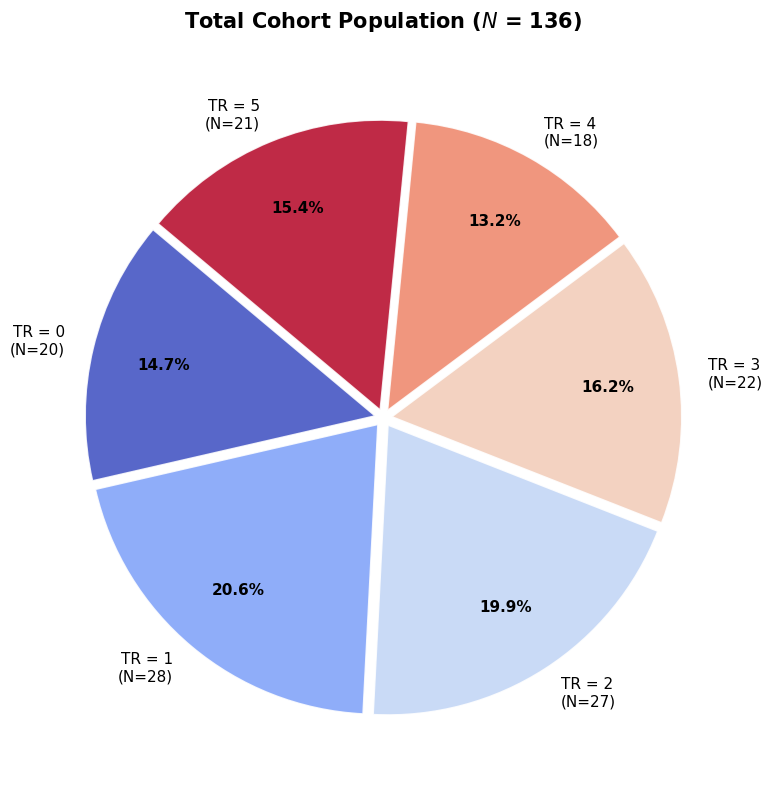

In [20]:
# 1. Prepare data and absolute counts
tr_counts = cohort_final["topological risk"].value_counts().sort_index()
total_patients = tr_counts.sum()

# Create clean labels showing both the TR group and absolute count (e.g., "TR = 0 (N=45)")
labels = [f"TR = {tr}\n(N={count})" for tr, count in zip(tr_counts.index, tr_counts.values)]

# 2. Plot setup
fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

# Explode slices slightly for better visual separation
explode = [0.03] * len(tr_counts)

# 3. Create the enhanced pie chart
wedges, texts, autotexts = ax.pie(
    tr_counts, 
    labels=labels,
    autopct='%1.1f%%',          # Adds percentage to each slice
    startangle=140,             # Rotates for better text balancing
    colors=umap_risk["color risk"], # Reuses your custom palette colors
    explode=explode,
    pctdistance=0.75,           # Distance of percentage text from center
    textprops=dict(color="black", fontsize=11, fontweight='medium'),
    wedgeprops=dict(edgecolor='white', linewidth=1, alpha=0.85)
)

# 4. Style the percentage texts inside the slices
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# 5. Descriptive elements
ax.set_title(
    f"Total Cohort Population ($N$ = {total_patients})", 
    fontsize=15, 
    fontweight='bold', 
    pad=20
)
fig.tight_layout()
fig.savefig(f"./test-pie_{cohort_name}-strata.svg", dpi=200, format="svg")

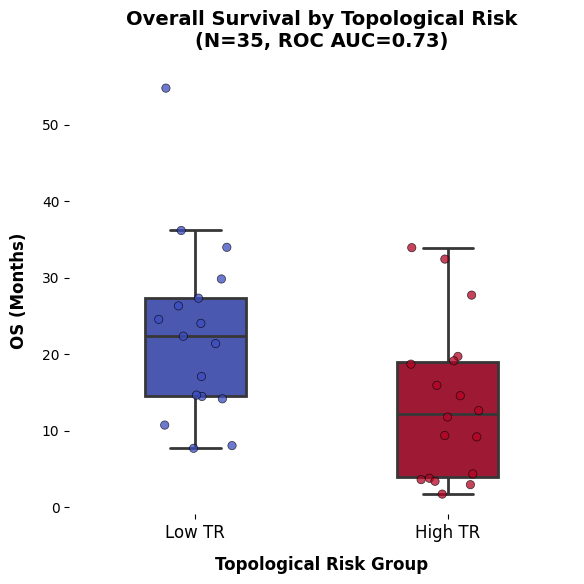

In [21]:
# Low TR group (topological risk = 0) vs High TR group (topological risk = 5)
low_TR = cohort_final.loc[(cohort_final["topological risk"]==0) & (cohort_final["status"]==1)].copy()
low_tr_os = low_TR["OS (days) - corrected"].values / daysXmonth
high_TR = cohort_final.loc[(cohort_final["topological risk"]==5) & (cohort_final["status"]==1)].copy()
high_tr_os = high_TR["OS (days) - corrected"].values / daysXmonth

# 2. Calculate the ROC AUC (Index)
# Group labels: 0 for Low TR, 1 for High TR
y_true = np.array([0] * len(low_tr_os) + [1] * len(high_tr_os))
# Scores: because higher TR implies shorter survival, we use negative OS as the indicator score for predicting High TR
y_scores = np.concatenate([-low_tr_os, -high_tr_os])
roc_auc = roc_auc_score(y_true, y_scores)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sns.set_theme(style="whitegrid")

labels = ['Low TR', 'High TR']
data = [low_tr_os, high_tr_os]
sns.boxplot(
    data=data, 
    palette=[[0.2298057 , 0.29871797, 0.75368315, 1.        ], [0.70567316, 0.01555616, 0.15023281, 1.        ]], 
    width=0.4, 
    linewidth=2, 
    fliersize=0, 
    ax=ax
)
# Add jittered points to show actual overlap density
sns.stripplot(
    data=data, 
    palette=[[0.2298057 , 0.29871797, 0.75368315, 1.        ], [0.70567316, 0.01555616, 0.15023281, 1.        ]], 
    size=6, 
    jitter=0.15, 
    alpha=0.75, 
    edgecolor='black', 
    linewidth=0.5, 
    ax=ax
)

ax.set_xticks(range(0, 2))
ax.set_title(f'Overall Survival by Topological Risk\n(N={len(data[0])+len(data[1])}, ROC AUC={roc_auc:.2f})', fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(labels, fontsize=12)
ax.set_xlabel('Topological Risk Group', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('OS (Months)', fontsize=12, fontweight='bold', labelpad=10)

sns.despine(left=True, bottom=True)
fig.tight_layout()
fig.savefig(f"./test-boxplot_{cohort_name}-strata.svg", dpi=200, format="svg")

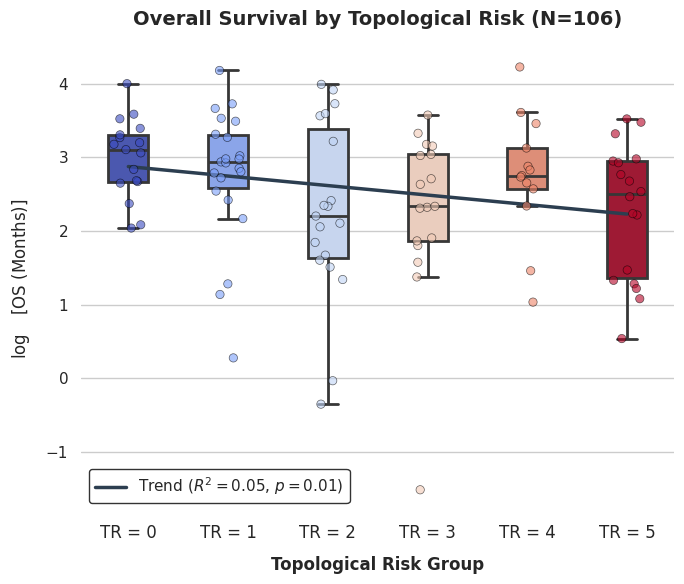

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sns.set_theme(style="whitegrid")

# 1. Prepare data structure
labels = [f"TR = {tr}" for tr in range(0, 6)]
data = [
    np.log(cohort_final.loc[(cohort_final["topological risk"] == tr) & (cohort_final["status"] == 1)]["OS (days) - corrected"].values / daysXmonth) 
    for tr in range(0, 6)
]
N_ = sum([len(d) for d in data])

# 2. Extract raw numbers for the linear regression
# This pairs every single patient's numeric TR with their numeric OS (Months)
valid_tr = cohort_final[cohort_final["topological risk"].isin(range(0, 6))]
x_raw = valid_tr["topological risk"].values
y_raw = np.log(valid_tr["OS (days) - corrected"].values / daysXmonth)

# Calculate linear regression metrics
slope, intercept, r_value, p_value, std_err = stats.linregress(x_raw, y_raw)
r2_value = r_value**2

# 3. Create Plots
sns.boxplot(
    data=data, 
    palette=umap_risk["color risk"].tolist(), 
    width=0.4, 
    linewidth=2, 
    fliersize=0, 
    ax=ax
)

sns.stripplot(
    data=data, 
    palette=umap_risk["color risk"].tolist(),
    size=6, 
    jitter=0.15, 
    alpha=0.6,          # Slightly reduced alpha so the regression line stands out
    edgecolor='black', 
    linewidth=0.5, 
    ax=ax
)

# 4. Add the Linear Regression Line
# The x-coordinates for categorical plots are indices 0 through 5
x_line = np.array(range(0, 6))
y_line = slope * x_line + intercept

ax.plot(
    x_line, 
    y_line, 
    color='#2c3e50',    # Elegant dark slate gray for contrast
    linestyle='-', 
    linewidth=2.5, 
    label=f'Trend ($R^2={r2_value:.2f}$, $p={p_value:.2f}$)'
)

# 5. Formatting and Polish
# Included regression stats right in the subtitle
ax.set_title(
    f'Overall Survival by Topological Risk '+f"(N={N_})",
    fontsize=14, 
    fontweight='bold', 
    pad=15
)
ax.set_xticks(range(0, 6))
ax.set_xticklabels(labels, fontsize=12)
ax.set_xlabel('Topological Risk Group', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel(r'$\log \quad [ \text{OS (Months)} ] \quad$', fontsize=12, fontweight='bold', labelpad=10)

# Add legend to display the trendline label
ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='black')

sns.despine(left=True, bottom=True)
fig.tight_layout()
fig.savefig(f"./test-loglinear_{cohort_name}-strata.svg", dpi=200, format="svg")

In [23]:
def plot_regression_analysis(true, pred, title, ax):
    # Calculate Statistics
    slope, intercept, r_value, p_value, std_err = stats.linregress(true, pred)
    r2 = r_value**2

    # Plot Diagonal (Perfect Agreement)
    max_val = max(true.max(), pred.max())
    ax.plot([0, max_val], [0, max_val], color='gray', linestyle='--', alpha=0.7, label='Perfect Agreement')

    # Regression Plot with CI
    p_value_text = f"p<0.01" if p_value < 0.01 else f"p={p_value:.2f}"
    sns.regplot(x=true, y=pred, ax=ax,
                scatter_kws={'alpha':0.5, 'color': '#2c3e50'},
                line_kws={'color': '#e74c3c', 'label': f'Linear Fit ($R^2={r2:.2f}, {p_value_text}$)'},
                truncate=False)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Observed OS (Months)")
    ax.set_ylabel("Predicted Lifetime (Months)")
    ax.legend(frameon=True)
    ax.grid(True, linestyle=':', alpha=0.6)

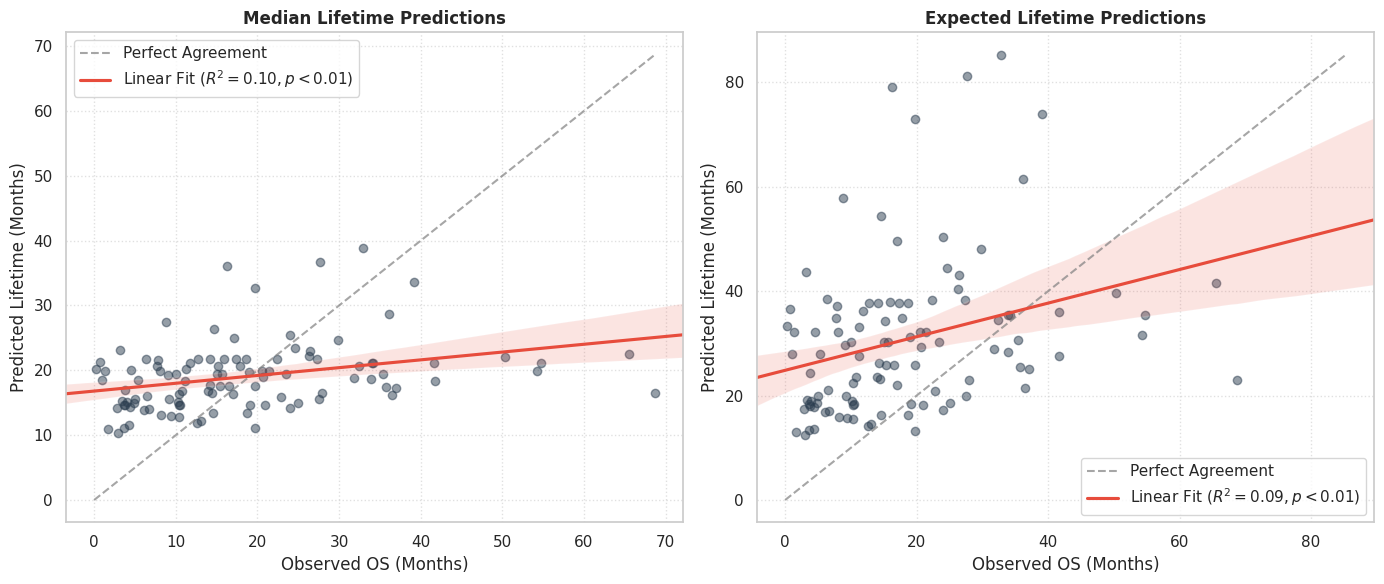

In [ ]:
cph_M1 = joblib.load("./cox_model_M1_preoperative.pkl")
preop_features_patient = ["age", "sex", "topological risk"]
uncensored_patients = cohort_final[cohort_final["status"]==1].copy() 

predicted_median_lifetimes_preop = cph_M1.predict_median(uncensored_patients[["OS (days) - corrected", "status"]+preop_features_patient]).values / daysXmonth
predicted_expected_lifetimes_preop = cph_M1.predict_expectation(uncensored_patients[["OS (days) - corrected", "status"]+preop_features_patient]).values / daysXmonth

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

plot_regression_analysis(uncensored_patients["OS (days) - corrected"] / daysXmonth, predicted_median_lifetimes_preop, "Median Lifetime Predictions", ax[0])
plot_regression_analysis(uncensored_patients["OS (days) - corrected"] / daysXmonth, predicted_expected_lifetimes_preop, "Expected Lifetime Predictions", ax[1])

fig.tight_layout()
fig.savefig(f"./test-regression_predictions_{cohort_name}_M1.svg", dpi=200, format="svg")

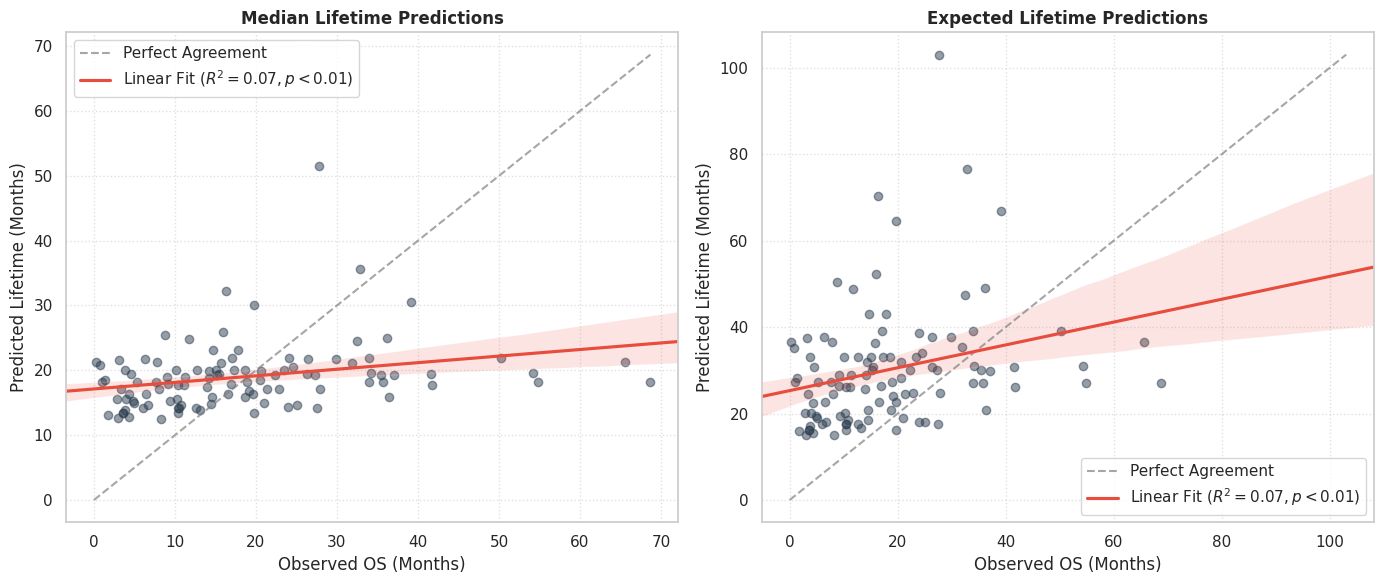

In [30]:
cph_M0 = joblib.load("./cox_model_M0_preoperative.pkl")
preop_features_patient = ["age", "sex"]
uncensored_patients = cohort_final[cohort_final["status"]==1].copy() 

predicted_median_lifetimes_preop = cph_M0.predict_median(uncensored_patients[["OS (days) - corrected", "status"]+preop_features_patient]).values / daysXmonth
predicted_expected_lifetimes_preop = cph_M0.predict_expectation(uncensored_patients[["OS (days) - corrected", "status"]+preop_features_patient]).values / daysXmonth

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

plot_regression_analysis(uncensored_patients["OS (days) - corrected"] / daysXmonth, predicted_median_lifetimes_preop, "Median Lifetime Predictions", ax[0])
plot_regression_analysis(uncensored_patients["OS (days) - corrected"] / daysXmonth, predicted_expected_lifetimes_preop, "Expected Lifetime Predictions", ax[1])

fig.tight_layout()
fig.savefig(f"./test-regression_predictions_{cohort_name}_M0.svg", dpi=200, format="svg")

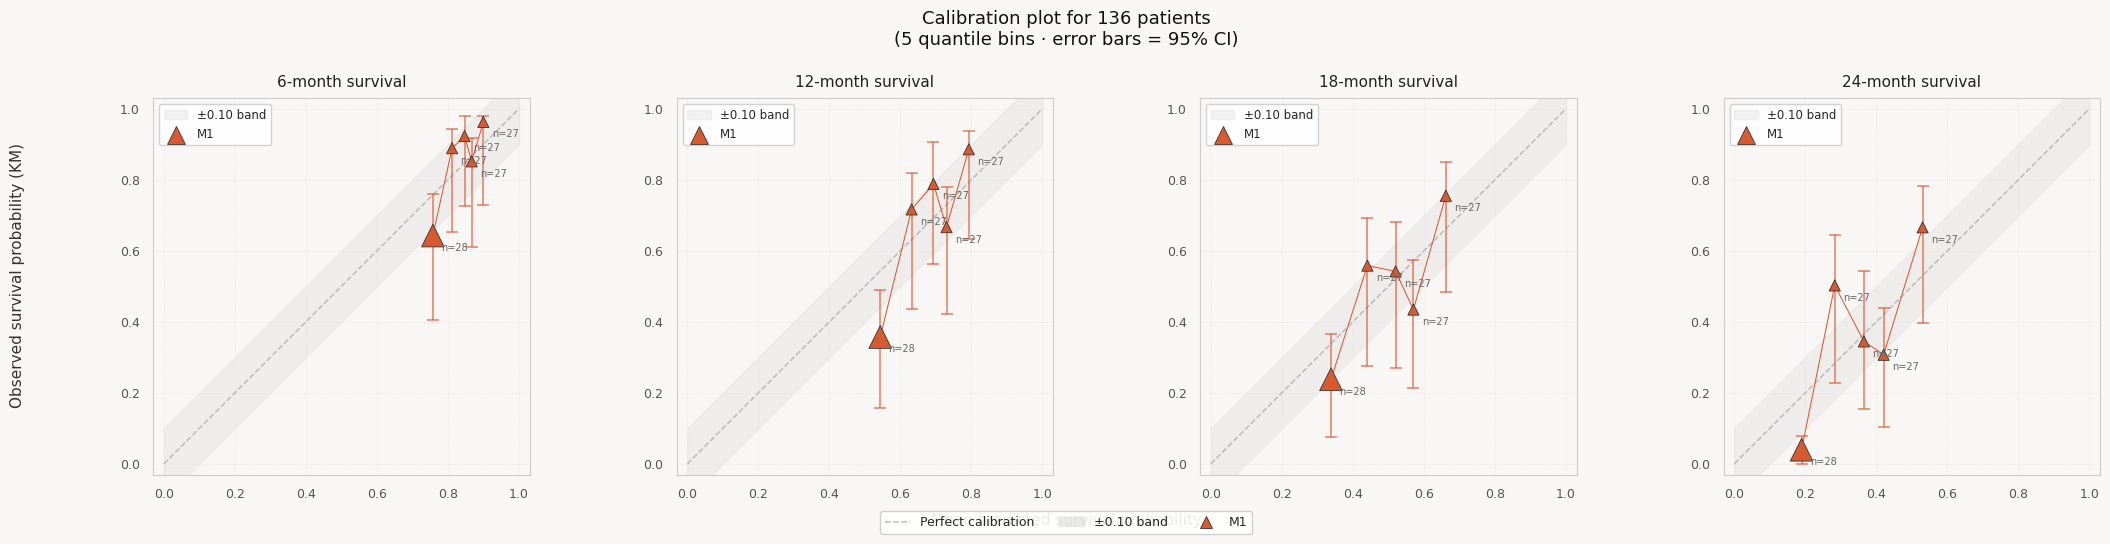

In [26]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────────
event_col  = "status"
time_col   = "OS (days) - corrected"
eval_times = [6, 12, 18, 24]   # one subplot each
n_bins     = 5

MODELS = {
    #"M0": {"model": cph_M0, "color": "#378ADD", "marker": "o"},  # blue  / circle
    "M1": {"model": cph_M1, "color": "#D85A30", "marker": "^"},  # coral / triangle
}
# ──────────────────────────────────────────────────────────────────────────────

def calibration_data(model, eval_time, cohort_final, daysXmonth):
    """Return per-bin calibration arrays for one model at one time point."""
    S_all = model.predict_survival_function(
        cohort_final, times=[daysXmonth * eval_time]
    )
    pred_probs = S_all.iloc[0].values

    tmp = cohort_final.copy()
    tmp["pred_surv"] = pred_probs
    tmp["risk_bin"], _ = pd.qcut(
        tmp["pred_surv"], q=n_bins,
        labels=False, retbins=True, duplicates="drop"
    )

    mean_pred, obs_km, n_per, ci_lo, ci_hi = [], [], [], [], []
    kmf = KaplanMeierFitter()

    for b in sorted(tmp["risk_bin"].dropna().unique()):
        grp = tmp[tmp["risk_bin"] == b]
        mean_pred.append(grp["pred_surv"].mean())

        kmf.fit(
            durations=grp[time_col] / daysXmonth,
            event_observed=grp[event_col]
        )
        obs_km.append(kmf.predict(eval_time))
        n_per.append(len(grp))

        tl  = kmf.confidence_interval_
        idx = min(np.searchsorted(tl.index, eval_time), len(tl) - 1)
        ci_lo.append(tl.iloc[idx, 0])
        ci_hi.append(tl.iloc[idx, 1])

    return dict(
        mean_pred = np.array(mean_pred),
        obs_km    = np.array(obs_km),
        n_per     = np.array(n_per),
        ci_lo     = np.array(ci_lo),
        ci_hi     = np.array(ci_hi),
    )

# ── Pre-compute all calibration data ─────────────────────────────────────────
results = {
    name: {t: calibration_data(cfg["model"], t, cohort_final, daysXmonth) for t in eval_times}
    for name, cfg in MODELS.items()
}

# ── Layout: 2×2 grid of subplots ─────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(eval_times) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.2 * nrows))
axes = axes.flatten()

fig.patch.set_facecolor("#F8F7F5")

for ax_idx, eval_time in enumerate(eval_times):
    try:
        ax = axes[ax_idx]
        ax.set_facecolor("#F8F7F5")

        for spine in ax.spines.values():
            spine.set_edgecolor("#CCCCCC")
            spine.set_linewidth(0.8)
        ax.tick_params(colors="#555555", labelsize=9)

        # Diagonal
        ax.plot([0, 1], [0, 1],
                color="#BBBBBB", linestyle="--", linewidth=1.1, zorder=1)

        # Shaded "acceptable" band ±0.10 around diagonal
        ax.fill_between([0, 1], [-0.10, 0.90], [0.10, 1.10],
                        color="#DDDDDD", alpha=0.35, zorder=0,
                        label="±0.10 band")

        for name, cfg in MODELS.items():
            res = results[name][eval_time]
            c, mk = cfg["color"], cfg["marker"]
            mp, ok, n = res["mean_pred"], res["obs_km"], res["n_per"]
            
            # Plot line connecting the points for this model and time
            ax.plot(mp, ok, color=c, linestyle="-", linewidth=.75, zorder=3)

            # Error bars
            ax.errorbar(
                mp, ok,
                yerr=[abs(ok - res["ci_lo"]), abs(res["ci_hi"] - ok)],
                fmt="none", ecolor=c,
                elinewidth=1.3, capsize=4, capthick=1.3,
                alpha=0.65, zorder=2
            )

            # Dots scaled by n
            sizes = 65 + 200 * (n - n.min()) / max(1, n.max() - n.min())
            ax.scatter(
                mp, ok,
                s=sizes, color=c, marker=mk,
                edgecolors="#333333", linewidths=0.6,
                zorder=3, label=name
            )

            # n= labels (only on the largest dot to avoid clutter)
            for x, y, ni in zip(mp, ok, n):
                ax.annotate(
                    f"n={ni}", xy=(x, y), xytext=(6, -11),
                    textcoords="offset points",
                    fontsize=7, color="#666666"
                )

        ax.set_title(f"{eval_time}-month survival", fontsize=11,
                    color="#222222", pad=8)
        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(-0.03, 1.03)
        ax.set_aspect("equal")
        ax.grid(True, color="#E0E0E0", linewidth=0.5, linestyle=":")

        # Per-subplot legend (only model names, no duplicates)
        handles, labels = ax.get_legend_handles_labels()
        # keep: ±0.10 band + M0 + M1
        seen, dedup_h, dedup_l = set(), [], []
        for h, l in zip(handles, labels):
            if l not in seen:
                seen.add(l)
                dedup_h.append(h)
                dedup_l.append(l)
        ax.legend(dedup_h, dedup_l, fontsize=8.5,
                framealpha=0.85, edgecolor="#CCCCCC", loc="upper left")
    except:
        print(f"Not enough eval_times to fill the grid for {eval_time}.")

# Shared axis labels
fig.text(0.5, 0.02, "Mean predicted survival probability",
         ha="center", fontsize=11, color="#333333")
fig.text(0.02, 0.5, "Observed survival probability (KM)",
         va="center", rotation="vertical", fontsize=11, color="#333333")

# Figure-level legend for markers/colors
legend_elements = [
    plt.Line2D([0], [0], color="#BBBBBB", linestyle="--",
               linewidth=1.1, label="Perfect calibration"),
    mpatches.Patch(color="#DDDDDD", alpha=0.6, label="±0.10 band"),
]
for name, cfg in MODELS.items():
    legend_elements.append(
        plt.Line2D([0], [0], marker=cfg["marker"], color="w",
                   markerfacecolor=cfg["color"], markeredgecolor="#333333",
                   markeredgewidth=0.6, markersize=9, label=name)
    )
fig.legend(handles=legend_elements, loc="lower center",
           ncol=len(legend_elements), fontsize=9,
           framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle(f"Calibration plot for {len(cohort_final)} patients\n"
             f"({n_bins} quantile bins · error bars = 95% CI)",
             fontsize=13, color="#111111", y=1.01)

fig.tight_layout(rect=[0.04, 0.06, 1, 1])
fig.savefig(f"./test-calibration_{cohort_name}.svg", dpi=200, format="svg")

# Showing that the outcome is not necessarily contingent on the number of graph theory metrics one chooses

In [31]:
seed_metrics = 6135798 # 698452, 6135798

### Random choice of metrics 1 --> 10 metrics

['avg_clustering', 'avg_percolation_centrality', 'avg_shortest_path_length', 'avg_rich_club_coef', 'avg_participation_coef', 'avg_edge_betwenness_centrality', 'modularity', 'LLR_distribution', 'avg_degree', 'global_efficiency']
Train: 861 Test: 136


/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Bootsrapping procedure: 100%|██████████| 50/50 [00:00<00:00, 4050.90it/s]


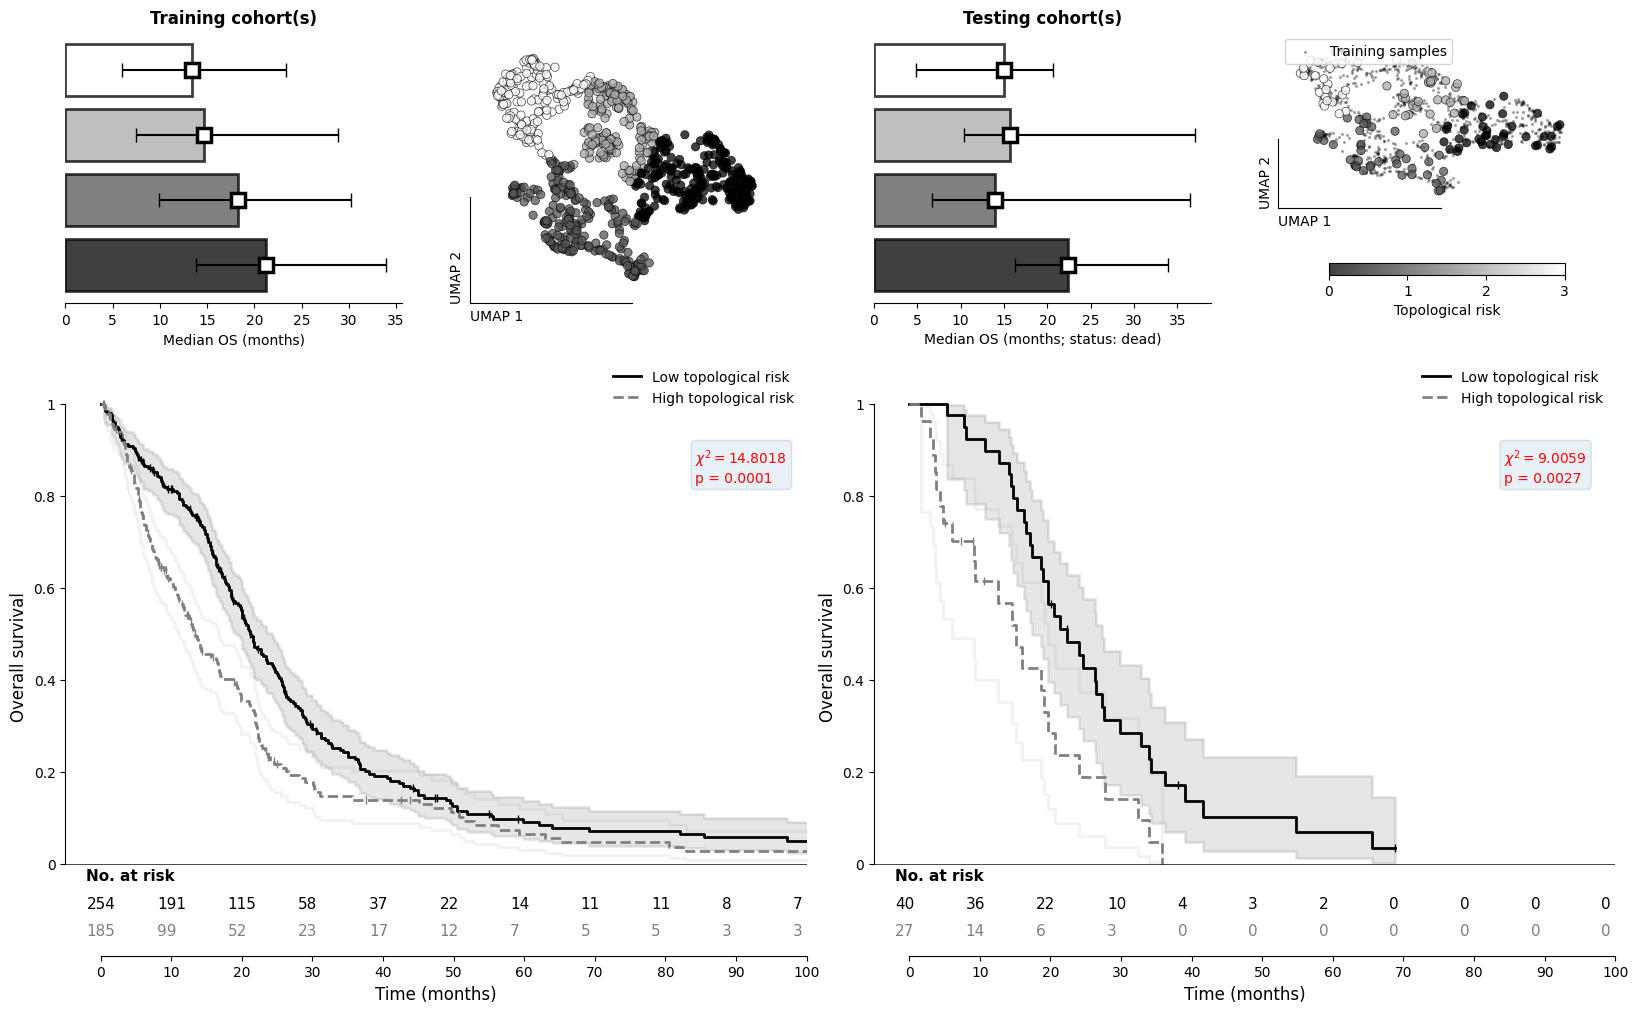

In [ ]:
##############################
### Choice of 10 metrics
np.random.seed(seed=seed_metrics)
metrics_covariates_subset = np.random.choice(metrics_covariates, size=10, replace=False).tolist()
print(metrics_covariates_subset)

##############################
### Split into train and test
custom = True
if custom is True:
    hcpex_train = hcpex_metrics.loc[hcpex_metrics["cohort"]<=1].copy() # UCSF + UPENN
    hcpex_test = hcpex_metrics.loc[hcpex_metrics["cohort"]>1].copy() # TCGA + RHUH
else:
    from sklearn.model_selection import train_test_split
    hcpex_train, hcpex_test = train_test_split(
        hcpex_metrics,
        test_size=0.2,       
        random_state=None,      
        shuffle=True,          
        stratify=hcpex_metrics["status"]
    )
    hcpex_train = hcpex_train.copy()
    hcpex_test  = hcpex_test.copy()

##############################
### These will be used to define the mapping between cluster labels and topological risk
mask_train = hcpex_train["status"]==1
os_train = hcpex_train["OS (days) - corrected"].values #hcpex_train.loc[mask_train, "OS (days) - corrected"],
status_train = hcpex_train["status"].values

##############################
### Standadizing the test sampmle based on the training distribution
st = 1
if st == 1:
    standard = StandardScaler(with_mean=True, with_std=True)
    hcpex_standard_train = standard.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_standard_test = standard.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_standard_train.copy(), hcpex_standard_test.copy()
elif st == 2:
    minmax = MinMaxScaler(feature_range=(0,1), clip=False)
    hcpex_minmax_train = minmax.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_minmax_test = minmax.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_minmax_train.copy(), hcpex_minmax_test.copy()
elif st == 3:
    robust = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), unit_variance=False)
    hcpex_robust_train = robust.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_robust_test = robust.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_robust_train.copy(), hcpex_robust_test.copy()
elif st == 4:
    powerT = PowerTransformer(method='yeo-johnson', standardize=True)
    hcpex_powerT_train = powerT.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_powerT_test = powerT.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_powerT_train.copy(), hcpex_powerT_test.copy()

N_train, N_test = len(data_train), len(data_test)
print("Train:", N_train, "Test:", N_test)

##############################
# Umap parameters --> to vary (https://umap-learn.readthedocs.io/en/latest/parameters.html)
umap_args = {
    "n_neighbors": 40,
    "n_components": 2,
    "metric": "euclidean",
    "random_state": 57463,
    "min_dist": .1,
    "spread": 1
}
# How can I fix the randomness?
ranking_method = "median-os"
##############################
### Define the clusterizer --> To vary (https://scikit-learn.org/stable/api/sklearn.cluster.html#)
risk_ = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    MeanShift(), # MeanShift requires using the components to define a bandwidth
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
)
clusterizer = MeanShift(
    bandwidth=estimate_bandwidth(
        risk_["umap coordinates: train"], 
        quantile=0.15, 
        n_samples=data_train.shape[0]
    )
)
#clusterizer = KMeans(n_clusters=4)

##############################
### Compute topological risk
umap_risk = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    clusterizer,
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
    cmap="gray",#"coolwarm", #
)

##############################
### Assign topological risk
hcpex_train["topological risk"] = umap_risk["topological risk: train"]
hcpex_test["topological risk"] = umap_risk["topological risk: test"]  

##############################
### Inspecting the outcomes to clarify the final stategy
fig, statistics = plot_umap_outcome(
    hcpex_train,
    umap_risk["umap coordinates: train"], # restricted the plot to 3 components in case of using more components
    hcpex_test,
    umap_risk["umap coordinates: test"],
    daysXmonth,
    umap_risk["color risk"],
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    cmap="gray",#"coolwarm", #
    months=range(0,110,10),
    show_median="all",
    plot=True
) 
statistics = clustering_metrics(umap_risk, statistics)
statistics = topological_risk_kendalltau(statistics)
statistics = topological_risk_concordance_index(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    alpha_CI=0.05,
    n_permutations=5000,
    n_bootstrap=5000,
    random_state=42
)
statistics = ranking_OS_topological_risk(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
)

In [33]:
fig.savefig(f"./test_10-metrics_seed-{seed_metrics}.svg", dpi=200, format="svg")

In [34]:
statistics["training cohort(s)"]["topological risk"]

{0: [np.float64(21.267316053350264),
  np.float64(13.841095890410958),
  np.float64(33.94844860690073)],
 1: [np.float64(18.317191466239567),
  np.float64(9.86310309720592),
  np.float64(30.246575342465754)],
 2: [np.float64(14.663013698630136),
  np.float64(7.52942245367059),
  np.float64(28.84077021727624)],
 3: [np.float64(13.385639917636604),
  np.float64(6.016438356164383),
  np.float64(23.336806435353292)]}

In [35]:
statistics["training cohort(s)"]["kaplan-meier"]

{'chi-squared': np.float64(14.80175119054334),
 'p-value': np.float64(0.0001194245510018582)}

In [36]:
statistics["training cohort(s)"]["cox model"]

{'C-index': np.float64(0.5619954084879665),
 'Log-likelihood ratio': np.float64(-4065.142506812996),
 'Hazard ratio and p-value': (np.float64(1.1433447540227706),
  np.float64(7.990036468693662e-05)),
 'C-index p-value (perm)': np.float64(0.0)}

### Random choice of metrics 2 --> 15 metrics

['avg_clustering', 'avg_percolation_centrality', 'avg_shortest_path_length', 'avg_rich_club_coef', 'avg_participation_coef', 'avg_edge_betwenness_centrality', 'modularity', 'LLR_distribution', 'avg_degree', 'global_efficiency', 'powerlaw_exponent', 'size', 'avg_local_efficiency', 'avg_betweenness_centrality', 'avg_closeness_centrality']
Train: 861 Test: 136


/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Bootsrapping procedure: 100%|██████████| 50/50 [00:00<00:00, 3958.38it/s]


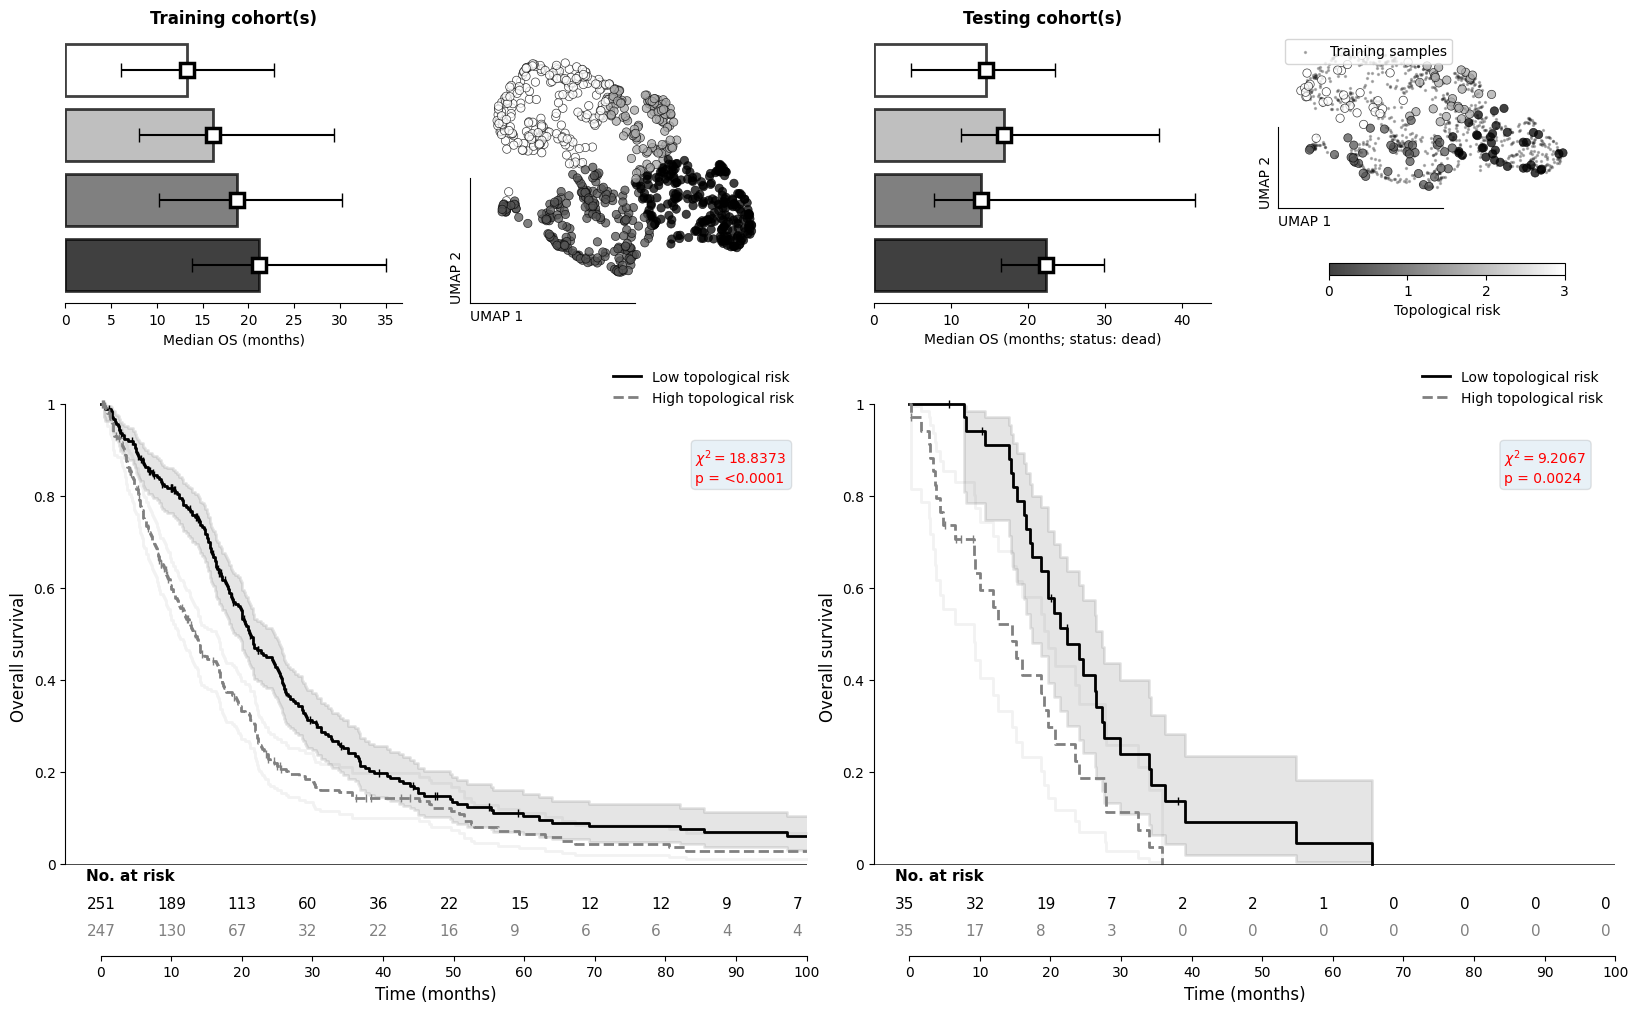

In [ ]:
##############################
### Choice of 15 metrics
np.random.seed(seed=seed_metrics)
metrics_covariates_subset = np.random.choice(metrics_covariates, size=15, replace=False).tolist()
print(metrics_covariates_subset)

##############################
### Split into train and test
custom = True
if custom is True:
    hcpex_train = hcpex_metrics.loc[hcpex_metrics["cohort"]<=1].copy() # UCSF + UPENN
    hcpex_test = hcpex_metrics.loc[hcpex_metrics["cohort"]>1].copy() # TCGA + RHUH
else:
    from sklearn.model_selection import train_test_split
    hcpex_train, hcpex_test = train_test_split(
        hcpex_metrics,
        test_size=0.2,       
        random_state=None,      
        shuffle=True,          
        stratify=hcpex_metrics["status"]
    )
    hcpex_train = hcpex_train.copy()
    hcpex_test  = hcpex_test.copy()

##############################
### These will be used to define the mapping between cluster labels and topological risk
mask_train = hcpex_train["status"]==1
os_train = hcpex_train["OS (days) - corrected"].values #hcpex_train.loc[mask_train, "OS (days) - corrected"],
status_train = hcpex_train["status"].values

##############################
### Standadizing the test sampmle based on the training distribution
st = 1
if st == 1:
    standard = StandardScaler(with_mean=True, with_std=True)
    hcpex_standard_train = standard.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_standard_test = standard.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_standard_train.copy(), hcpex_standard_test.copy()
elif st == 2:
    minmax = MinMaxScaler(feature_range=(0,1), clip=False)
    hcpex_minmax_train = minmax.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_minmax_test = minmax.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_minmax_train.copy(), hcpex_minmax_test.copy()
elif st == 3:
    robust = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), unit_variance=False)
    hcpex_robust_train = robust.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_robust_test = robust.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_robust_train.copy(), hcpex_robust_test.copy()
elif st == 4:
    powerT = PowerTransformer(method='yeo-johnson', standardize=True)
    hcpex_powerT_train = powerT.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_powerT_test = powerT.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_powerT_train.copy(), hcpex_powerT_test.copy()

N_train, N_test = len(data_train), len(data_test)
print("Train:", N_train, "Test:", N_test)

##############################
# Umap parameters --> to vary (https://umap-learn.readthedocs.io/en/latest/parameters.html)
umap_args = {
    "n_neighbors": 40,
    "n_components": 2,
    "metric": "euclidean",
    "random_state": 57463,
    "min_dist": .1,
    "spread": 1
}
# How can I fix the randomness?
ranking_method = "median-os"
##############################
### Define the clusterizer --> To vary (https://scikit-learn.org/stable/api/sklearn.cluster.html#)
risk_ = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    MeanShift(), # MeanShift requires using the components to define a bandwidth
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
)
clusterizer = MeanShift(
    bandwidth=estimate_bandwidth(
        risk_["umap coordinates: train"], 
        quantile=0.15, 
        n_samples=data_train.shape[0]
    )
)
#clusterizer = KMeans(n_clusters=4)

##############################
### Compute topological risk
umap_risk = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    clusterizer,
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
    cmap="gray",#"coolwarm", #
)

##############################
### Assign topological risk
hcpex_train["topological risk"] = umap_risk["topological risk: train"]
hcpex_test["topological risk"] = umap_risk["topological risk: test"]  

##############################
### Inspecting the outcomes to clarify the final stategy
fig, statistics = plot_umap_outcome(
    hcpex_train,
    umap_risk["umap coordinates: train"], # restricted the plot to 3 components in case of using more components
    hcpex_test,
    umap_risk["umap coordinates: test"],
    daysXmonth,
    umap_risk["color risk"],
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    cmap="gray",#"coolwarm", #
    months=range(0,110,10),
    show_median="all",
    plot=True
) 
statistics = clustering_metrics(umap_risk, statistics)
statistics = topological_risk_kendalltau(statistics)
statistics = topological_risk_concordance_index(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    alpha_CI=0.05,
    n_permutations=5000,
    n_bootstrap=5000,
    random_state=42
)
statistics = ranking_OS_topological_risk(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
)

In [38]:
fig.savefig(f"./test_15-metrics_seed-{seed_metrics}.svg", dpi=200, format="svg")

In [39]:
statistics["training cohort(s)"]["topological risk"]

{0: [np.float64(21.13522092258411),
  np.float64(13.841095890410958),
  np.float64(35.049241363285326)],
 1: [np.float64(18.801540279048787),
  np.float64(10.259388489504373),
  np.float64(30.213698630136985)],
 2: [np.float64(16.142465753424656),
  np.float64(8.054794520547945),
  np.float64(29.325119030085457)],
 3: [np.float64(13.297576497125839),
  np.float64(6.082191780821917),
  np.float64(22.80842591228869)]}

In [40]:
statistics["training cohort(s)"]["kaplan-meier"]

{'chi-squared': np.float64(18.837292805578173),
 'p-value': np.float64(1.4235631945402942e-05)}

In [41]:
statistics["training cohort(s)"]["cox model"]

{'C-index': np.float64(0.5652907679953618),
 'Log-likelihood ratio': np.float64(-4063.204650708419),
 'Hazard ratio and p-value': (np.float64(1.1519504332869035),
  np.float64(1.0429746176620088e-05)),
 'C-index p-value (perm)': np.float64(0.0)}

### Random choice of metrics 3 --> 5 metrics

['avg_clustering', 'avg_percolation_centrality', 'avg_shortest_path_length', 'avg_rich_club_coef', 'avg_participation_coef']
Train: 861 Test: 136


/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Bootsrapping procedure: 100%|██████████| 50/50 [00:00<00:00, 3981.00it/s]


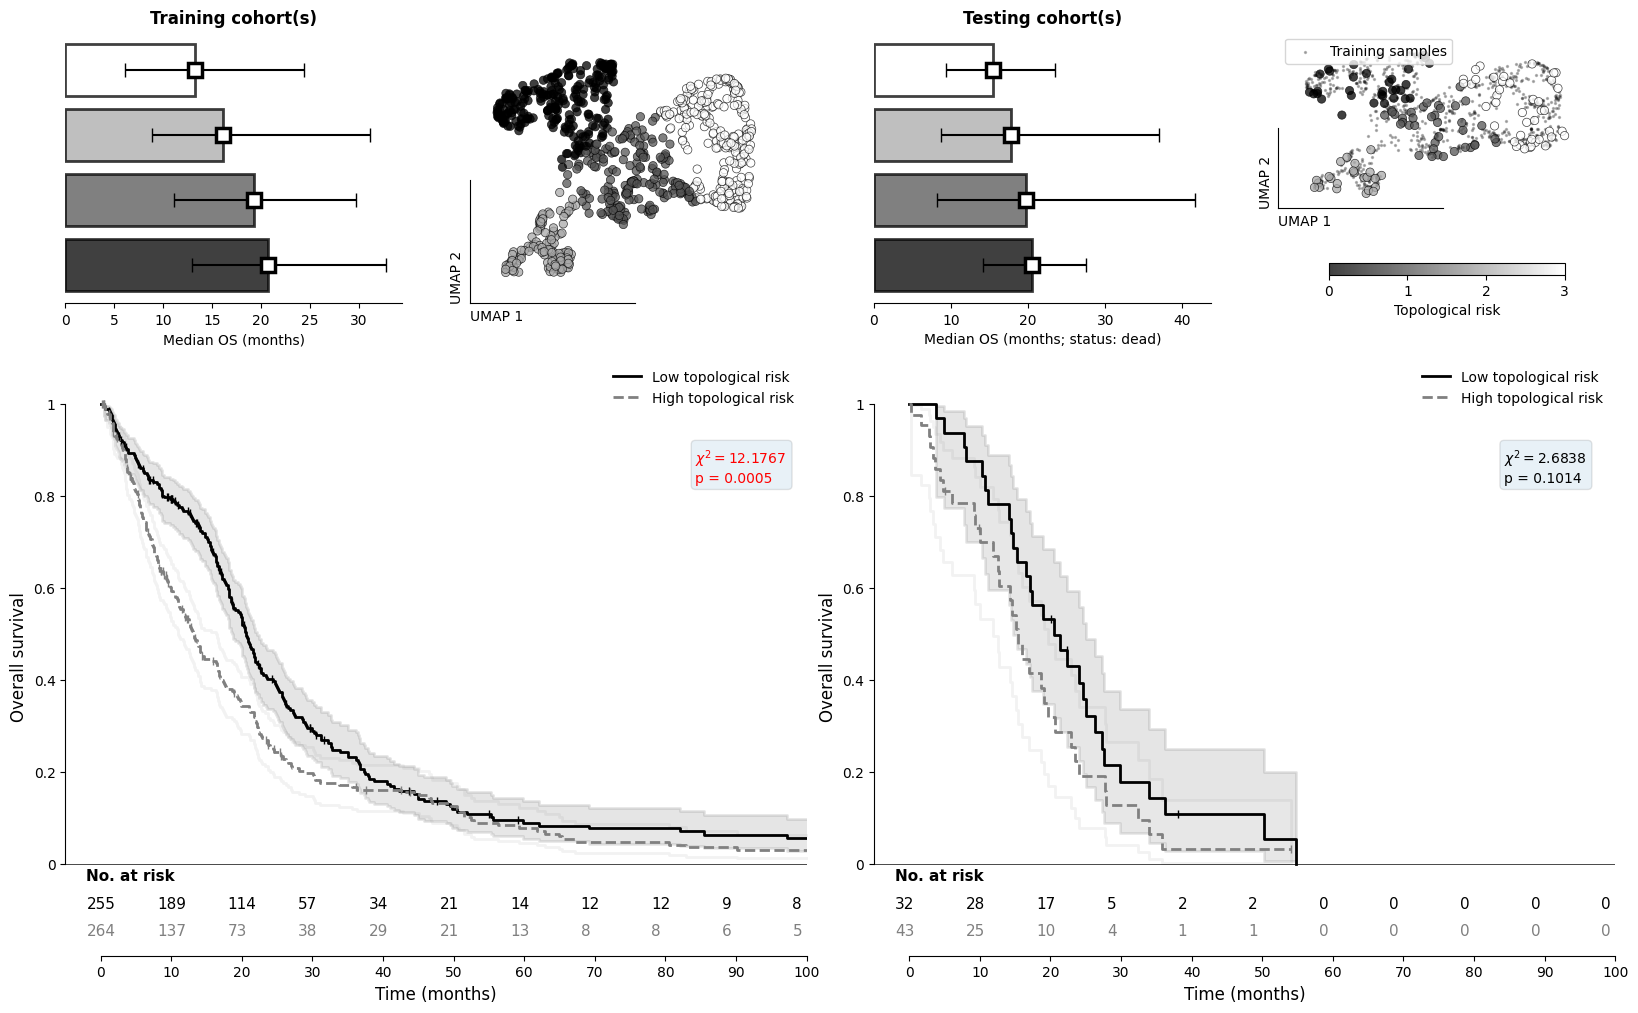

In [ ]:
##############################
### Choice of 5 metrics
np.random.seed(seed=seed_metrics)
metrics_covariates_subset = np.random.choice(metrics_covariates, size=5, replace=False).tolist()
print(metrics_covariates_subset)

##############################
### Split into train and test
custom = True
if custom is True:
    hcpex_train = hcpex_metrics.loc[hcpex_metrics["cohort"]<=1].copy() # UCSF + UPENN
    hcpex_test = hcpex_metrics.loc[hcpex_metrics["cohort"]>1].copy() # TCGA + RHUH
else:
    from sklearn.model_selection import train_test_split
    hcpex_train, hcpex_test = train_test_split(
        hcpex_metrics,
        test_size=0.2,       
        random_state=None,      
        shuffle=True,          
        stratify=hcpex_metrics["status"]
    )
    hcpex_train = hcpex_train.copy()
    hcpex_test  = hcpex_test.copy()

##############################
### These will be used to define the mapping between cluster labels and topological risk
mask_train = hcpex_train["status"]==1
os_train = hcpex_train["OS (days) - corrected"].values #hcpex_train.loc[mask_train, "OS (days) - corrected"],
status_train = hcpex_train["status"].values

##############################
### Standadizing the test sampmle based on the training distribution
st = 1
if st == 1:
    standard = StandardScaler(with_mean=True, with_std=True)
    hcpex_standard_train = standard.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_standard_test = standard.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_standard_train.copy(), hcpex_standard_test.copy()
elif st == 2:
    minmax = MinMaxScaler(feature_range=(0,1), clip=False)
    hcpex_minmax_train = minmax.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_minmax_test = minmax.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_minmax_train.copy(), hcpex_minmax_test.copy()
elif st == 3:
    robust = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), unit_variance=False)
    hcpex_robust_train = robust.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_robust_test = robust.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_robust_train.copy(), hcpex_robust_test.copy()
elif st == 4:
    powerT = PowerTransformer(method='yeo-johnson', standardize=True)
    hcpex_powerT_train = powerT.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_powerT_test = powerT.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_powerT_train.copy(), hcpex_powerT_test.copy()

N_train, N_test = len(data_train), len(data_test)
print("Train:", N_train, "Test:", N_test)

##############################
# Umap parameters --> to vary (https://umap-learn.readthedocs.io/en/latest/parameters.html)
umap_args = {
    "n_neighbors": 40,
    "n_components": 2,
    "metric": "euclidean",
    "random_state": 57463,
    "min_dist": .1,
    "spread": 1
}
# How can I fix the randomness?
ranking_method = "median-os"
##############################
### Define the clusterizer --> To vary (https://scikit-learn.org/stable/api/sklearn.cluster.html#)
risk_ = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    MeanShift(), # MeanShift requires using the components to define a bandwidth
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
)
clusterizer = MeanShift(
    bandwidth=estimate_bandwidth(
        risk_["umap coordinates: train"], 
        quantile=0.15, 
        n_samples=data_train.shape[0]
    )
)
#clusterizer = KMeans(n_clusters=4)

##############################
### Compute topological risk
umap_risk = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    clusterizer,
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
    cmap="gray",#"coolwarm", #
)

##############################
### Assign topological risk
hcpex_train["topological risk"] = umap_risk["topological risk: train"]
hcpex_test["topological risk"] = umap_risk["topological risk: test"]  

##############################
### Inspecting the outcomes to clarify the final stategy
fig, statistics = plot_umap_outcome(
    hcpex_train,
    umap_risk["umap coordinates: train"], # restricted the plot to 3 components in case of using more components
    hcpex_test,
    umap_risk["umap coordinates: test"],
    daysXmonth,
    umap_risk["color risk"],
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    cmap="gray",#"coolwarm", #
    months=range(0,110,10),
    show_median="all",
    plot=True
) 
statistics = clustering_metrics(umap_risk, statistics)
statistics = topological_risk_kendalltau(statistics)
statistics = topological_risk_concordance_index(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    alpha_CI=0.05,
    n_permutations=5000,
    n_bootstrap=5000,
    random_state=42
)
statistics = ranking_OS_topological_risk(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
)

In [43]:
fig.savefig(f"./test_5-metrics_seed-{seed_metrics}.svg", dpi=200, format="svg")

In [44]:
statistics["training cohort(s)"]["topological risk"]

{0: [np.float64(20.646575342465752),
  np.float64(12.953424657534246),
  np.float64(32.75959243000538)],
 1: [np.float64(19.24185738160262),
  np.float64(11.140022694612043),
  np.float64(29.63334100187315)],
 2: [np.float64(16.142465753424656),
  np.float64(8.806342051076715),
  np.float64(31.130419150556186)],
 3: [np.float64(13.253544786870457),
  np.float64(6.076376015242932),
  np.float64(24.3935674814825)]}

In [45]:
statistics["training cohort(s)"]["kaplan-meier"]

{'chi-squared': np.float64(12.176660589279646),
 'p-value': np.float64(0.00048391199864315944)}

In [46]:
statistics["training cohort(s)"]["cox model"]

{'C-index': np.float64(0.560822540392311),
 'Log-likelihood ratio': np.float64(-4066.043980573778),
 'Hazard ratio and p-value': (np.float64(1.1232766893159294),
  np.float64(0.00022477204788234808)),
 'C-index p-value (perm)': np.float64(0.0)}

### Random choice of 2 metrics

['avg_clustering', 'avg_percolation_centrality']
Train: 861 Test: 136


/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/joan/.conda/envs/neuroimaging/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Bootsrapping procedure: 100%|██████████| 50/50 [00:00<00:00, 3799.19it/s]


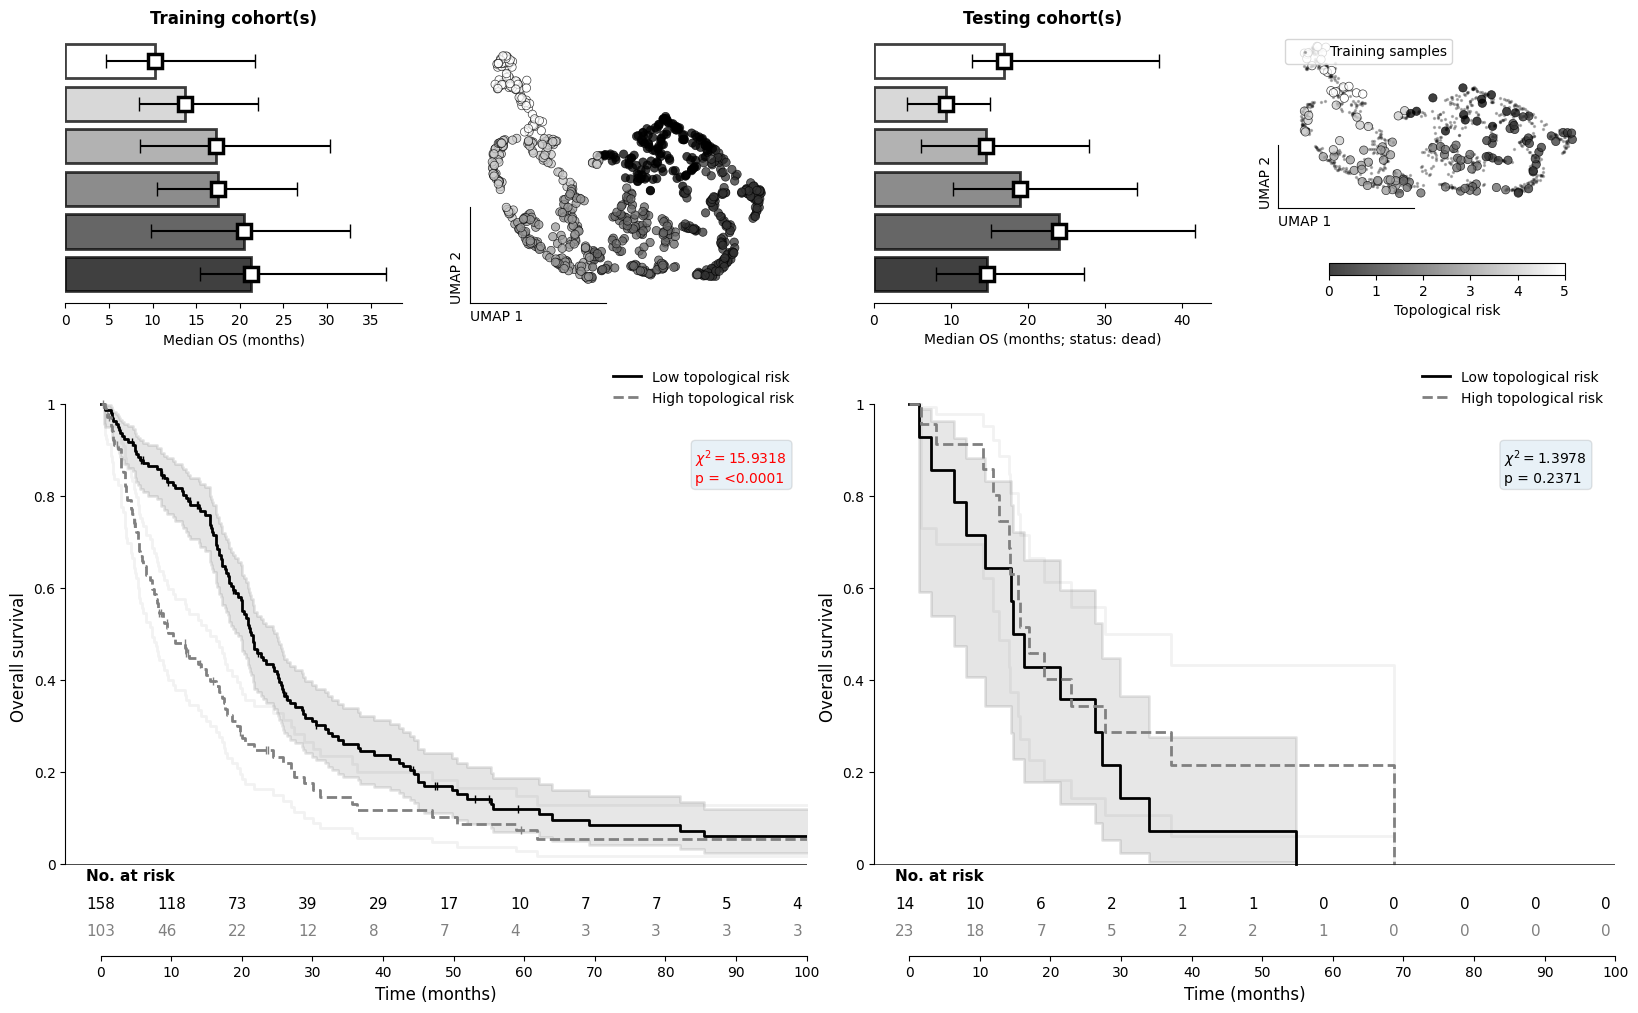

In [ ]:
##############################
### Choice of 2 metrics
np.random.seed(seed=seed_metrics)
metrics_covariates_subset = np.random.choice(metrics_covariates, size=2, replace=False).tolist()
print(metrics_covariates_subset)

##############################
### Split into train and test
custom = True
if custom is True:
    hcpex_train = hcpex_metrics.loc[hcpex_metrics["cohort"]<=1].copy() # UCSF + UPENN
    hcpex_test = hcpex_metrics.loc[hcpex_metrics["cohort"]>1].copy() # TCGA + RHUH
else:
    from sklearn.model_selection import train_test_split
    hcpex_train, hcpex_test = train_test_split(
        hcpex_metrics,
        test_size=0.2,       
        random_state=None,      
        shuffle=True,          
        stratify=hcpex_metrics["status"]
    )
    hcpex_train = hcpex_train.copy()
    hcpex_test  = hcpex_test.copy()

##############################
### These will be used to define the mapping between cluster labels and topological risk
mask_train = hcpex_train["status"]==1
os_train = hcpex_train["OS (days) - corrected"].values #hcpex_train.loc[mask_train, "OS (days) - corrected"],
status_train = hcpex_train["status"].values

##############################
### Standadizing the test sampmle based on the training distribution
st = 1
if st == 1:
    standard = StandardScaler(with_mean=True, with_std=True)
    hcpex_standard_train = standard.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_standard_test = standard.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_standard_train.copy(), hcpex_standard_test.copy()
elif st == 2:
    minmax = MinMaxScaler(feature_range=(0,1), clip=False)
    hcpex_minmax_train = minmax.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_minmax_test = minmax.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_minmax_train.copy(), hcpex_minmax_test.copy()
elif st == 3:
    robust = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), unit_variance=False)
    hcpex_robust_train = robust.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_robust_test = robust.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_robust_train.copy(), hcpex_robust_test.copy()
elif st == 4:
    powerT = PowerTransformer(method='yeo-johnson', standardize=True)
    hcpex_powerT_train = powerT.fit_transform(hcpex_train[metrics_covariates_subset])
    hcpex_powerT_test = powerT.transform(hcpex_test[metrics_covariates_subset])
    data_train, data_test = hcpex_powerT_train.copy(), hcpex_powerT_test.copy()

N_train, N_test = len(data_train), len(data_test)
print("Train:", N_train, "Test:", N_test)

##############################
# Umap parameters --> to vary (https://umap-learn.readthedocs.io/en/latest/parameters.html)
umap_args = {
    "n_neighbors": 40,
    "n_components": 2,
    "metric": "euclidean",
    "random_state": 57463,
    "min_dist": .1,
    "spread": 1
}
# How can I fix the randomness?
ranking_method = "median-os"
##############################
### Define the clusterizer --> To vary (https://scikit-learn.org/stable/api/sklearn.cluster.html#)
risk_ = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    MeanShift(), # MeanShift requires using the components to define a bandwidth
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
)
clusterizer = MeanShift(
    bandwidth=estimate_bandwidth(
        risk_["umap coordinates: train"], 
        quantile=0.15, 
        n_samples=data_train.shape[0]
    )
)
#clusterizer = KMeans(n_clusters=4)

##############################
### Compute topological risk
umap_risk = compute_topological_risk(
    umap_args,
    data_train,
    data_test,
    clusterizer,
    mask_train,
    os_train,
    status_train,
    method=ranking_method,
    cmap="gray",#"coolwarm", #
)

##############################
### Assign topological risk
hcpex_train["topological risk"] = umap_risk["topological risk: train"]
hcpex_test["topological risk"] = umap_risk["topological risk: test"]  

##############################
### Inspecting the outcomes to clarify the final stategy
fig, statistics = plot_umap_outcome(
    hcpex_train,
    umap_risk["umap coordinates: train"], # restricted the plot to 3 components in case of using more components
    hcpex_test,
    umap_risk["umap coordinates: test"],
    daysXmonth,
    umap_risk["color risk"],
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    cmap="gray",#"coolwarm", #
    months=range(0,110,10),
    show_median="all",
    plot=True
) 
statistics = clustering_metrics(umap_risk, statistics)
statistics = topological_risk_kendalltau(statistics)
statistics = topological_risk_concordance_index(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
    alpha_CI=0.05,
    n_permutations=5000,
    n_bootstrap=5000,
    random_state=42
)
statistics = ranking_OS_topological_risk(
    statistics,
    hcpex_train,
    hcpex_test,
    status="status",
    risk="topological risk",
    survival="OS (days) - corrected",
)

In [48]:
fig.savefig(f"./test_2-metrics_seed-{seed_metrics}.svg", dpi=200, format="svg")

In [49]:
statistics["training cohort(s)"]["topological risk"]

{0: [np.float64(21.267316053350264),
  np.float64(15.484931506849314),
  np.float64(36.78904109589041)],
 1: [np.float64(20.515068493150682),
  np.float64(9.797260273972602),
  np.float64(32.671529009494606)],
 2: [np.float64(17.523287671232875),
  np.float64(10.487671232876712),
  np.float64(26.5972602739726)],
 3: [np.float64(17.26043042011036),
  np.float64(8.586183499799796),
  np.float64(30.293816655703896)],
 4: [np.float64(13.70958904109589),
  np.float64(8.410056658778261),
  np.float64(22.147950258457936)],
 5: [np.float64(10.29041095890411),
  np.float64(4.668493150684931),
  np.float64(21.7076331559041)]}

In [50]:
statistics["training cohort(s)"]["kaplan-meier"]

{'chi-squared': np.float64(15.931756405123572),
 'p-value': np.float64(6.566764509793444e-05)}

In [51]:
statistics["training cohort(s)"]["cox model"]

{'C-index': np.float64(0.5697340055111473),
 'Log-likelihood ratio': np.float64(-4062.588790285166),
 'Hazard ratio and p-value': (np.float64(1.110929273309778),
  np.float64(5.3303464153365736e-06)),
 'C-index p-value (perm)': np.float64(0.0)}